# Hybrid IDS Research Analysis

This notebook supports the project **AI-Powered Intrusion Detection System Using a Hybrid Machine Learning Architecture**. It loads UNSW-NB15 CSV files when available and falls back to a reproducible UNSW-NB15-like demonstration dataset so the notebook can execute end-to-end without manual changes.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.datasets import make_classification
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix, f1_score,
    precision_recall_curve, precision_score, recall_score, roc_auc_score,
    roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
ROOT = Path.cwd()
DATA_DIR = ROOT / "data"
CHART_DIR = ROOT / "charts"
METRICS_DIR = ROOT / "metrics"
CHART_DIR.mkdir(exist_ok=True)
METRICS_DIR.mkdir(exist_ok=True)
RANDOM_STATE = 42

## 1. Introduction

The objective is to evaluate an intrusion detection system that combines supervised ensemble learning and anomaly detection. UNSW-NB15 is selected because it includes modern attack categories, normal traffic, binary labels, and network-flow features suitable for machine learning.

## 2. Dataset Loading

Place UNSW-NB15 CSV files in the `data/` directory. The loader searches for CSV files and combines them. If no real dataset exists, a reproducible demonstration dataset is generated so every section remains executable.

In [2]:
ATTACK_CATEGORIES = [
    "Analysis", "Backdoor", "DoS", "Exploits", "Fuzzers",
    "Generic", "Reconnaissance", "Shellcode", "Worms"
]

def make_demo_dataset(n_samples=2500, n_features=20):
    x, y = make_classification(
        n_samples=n_samples, n_features=n_features, n_informative=12,
        n_redundant=4, n_clusters_per_class=2, weights=[0.64, 0.36],
        class_sep=1.25, random_state=RANDOM_STATE
    )
    columns = [
        "dur", "spkts", "dpkts", "sbytes", "dbytes", "rate", "sttl", "dttl",
        "sload", "dload", "sloss", "dloss", "sinpkt", "dinpkt", "sjit",
        "djit", "swin", "stcpb", "dtcpb", "dwin"
    ][:n_features]
    df = pd.DataFrame(x, columns=columns)
    rng = np.random.default_rng(RANDOM_STATE)
    df["label"] = y
    df["attack_cat"] = np.where(df["label"].eq(0), "Normal", rng.choice(ATTACK_CATEGORIES, len(df)))
    return df

def load_dataset():
    csv_files = sorted(DATA_DIR.glob("*.csv"))
    if csv_files:
        df = pd.concat((pd.read_csv(path) for path in csv_files), ignore_index=True)
        source = f"Loaded {len(csv_files)} CSV file(s) from {DATA_DIR}"
    else:
        df = make_demo_dataset()
        source = "Generated reproducible UNSW-NB15-like demonstration dataset"
    return df, source

df, source = load_dataset()
print(source)
df.head()

Loaded 1 CSV file(s) from C:\Users\sambhram.u\Desktop\Research\data


,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,...,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,attack_cat,label
0,-0.068030,-1.453039,0.544250,3.600291,-2.610956,1.243998,-1.312102,2.113712,1.454453,0.064093,...,0.172371,-0.227065,3.027936,-3.894269,3.019825,-0.461648,1.828296,7.424977,Analysis,1
1,-1.385664,-1.424126,-0.927113,4.503058,-4.755284,-2.939000,2.497700,-2.500041,0.145569,0.837571,...,-11.966704,-0.754718,-0.435416,0.515100,4.402340,-0.732410,-2.031724,-0.681696,Normal,0
2,-1.944454,1.930961,3.961469,-0.385478,1.310528,0.828405,-0.837293,3.119180,-0.051308,-2.174303,...,5.231625,1.371271,-2.549537,-2.435577,0.396900,-0.135360,0.073552,1.817813,Generic,1
3,3.552263,-4.968769,-2.335410,2.964491,-5.900068,1.502684,-1.292384,0.377790,-0.697632,-0.261506,...,-3.292424,1.527185,2.562319,-1.619194,3.527344,-0.284346,2.664544,3.395868,Exploits,1
4,0.864794,0.312603,5.064508,2.990340,3.265076,1.083882,2.485838,3.486410,-1.355893,-0.540723,...,14.390279,-0.421432,-3.390506,-2.198769,-0.300238,0.553506,0.507358,1.119576,Exploits,1


## 3. Exploratory Data Analysis

This section checks shape, null values, attack distribution, class imbalance, summary statistics, and core visualization patterns.

In [3]:
print("Shape:", df.shape)
display(df.isna().sum().sort_values(ascending=False).head(15).to_frame("null_count"))
display(df["label"].value_counts().rename(index={0: "Normal", 1: "Attack"}).to_frame("count"))
if "attack_cat" in df.columns:
    display(df["attack_cat"].value_counts().to_frame("count"))
display(df.describe(include="all").T.head(20))

Shape: (2500, 22)


,null_count
dur,0
spkts,0
attack_cat,0
dwin,0
dtcpb,0
stcpb,0
swin,0
djit,0
sjit,0
dinpkt,0


,count
label,
Normal,1597
Attack,903


,count
attack_cat,
Normal,1597
Backdoor,113
DoS,110
Fuzzers,108
Analysis,100
Generic,100
Reconnaissance,98
Exploits,95
Worms,93


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
dur,2500.0,NaN,NaN,NaN,-0.820871,2.171473,-7.250397,-2.27026,-0.864673,0.591933,7.779223
spkts,2500.0,NaN,NaN,NaN,0.749569,2.140631,-6.060851,-0.663867,0.769987,2.203554,8.610286
dpkts,2500.0,NaN,NaN,NaN,-1.364396,4.917648,-19.234967,-4.724539,-1.246654,1.906117,17.299218
sbytes,2500.0,NaN,NaN,NaN,-0.053134,2.551534,-9.058177,-1.841511,-0.056905,1.723833,8.002117
dbytes,2500.0,NaN,NaN,NaN,-0.430574,2.398248,-7.689325,-2.054348,-0.566437,1.169178,8.273274
rate,2500.0,NaN,NaN,NaN,0.418972,2.340784,-8.102869,-1.252146,0.456739,2.059912,8.220384
sttl,2500.0,NaN,NaN,NaN,0.017565,3.961329,-13.902295,-2.620753,0.009281,2.674958,13.883563
dttl,2500.0,NaN,NaN,NaN,-0.841423,1.990043,-7.988697,-2.189922,-0.948624,0.443872,5.471897
sload,2500.0,NaN,NaN,NaN,0.009322,0.994295,-3.221167,-0.654299,0.012948,0.698942,3.295904
dload,2500.0,NaN,NaN,NaN,0.034119,2.461514,-10.847637,-1.670056,0.070262,1.709164,8.800115


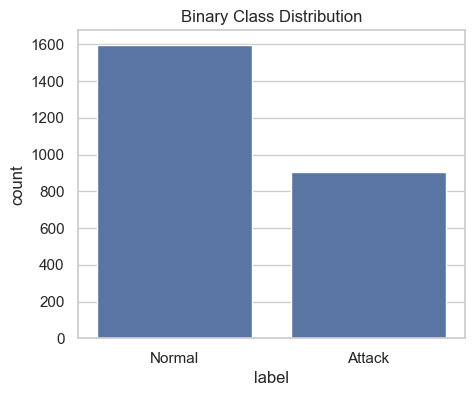

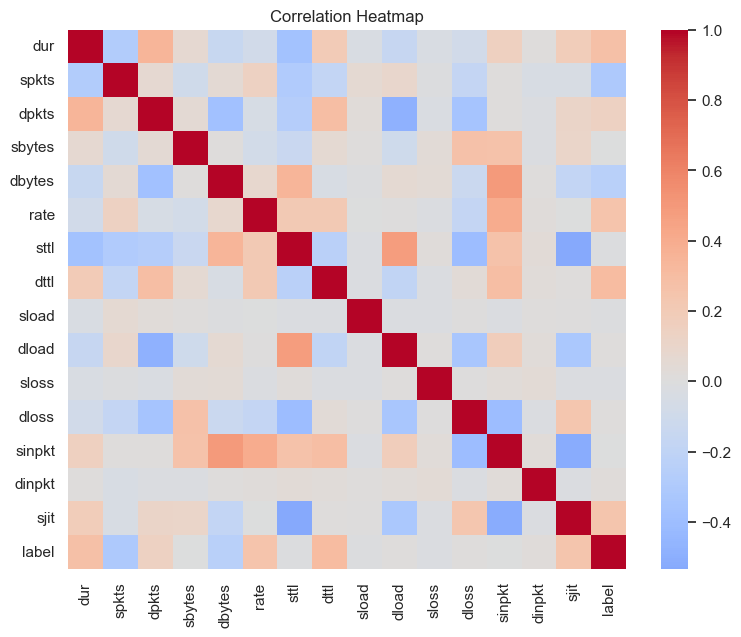

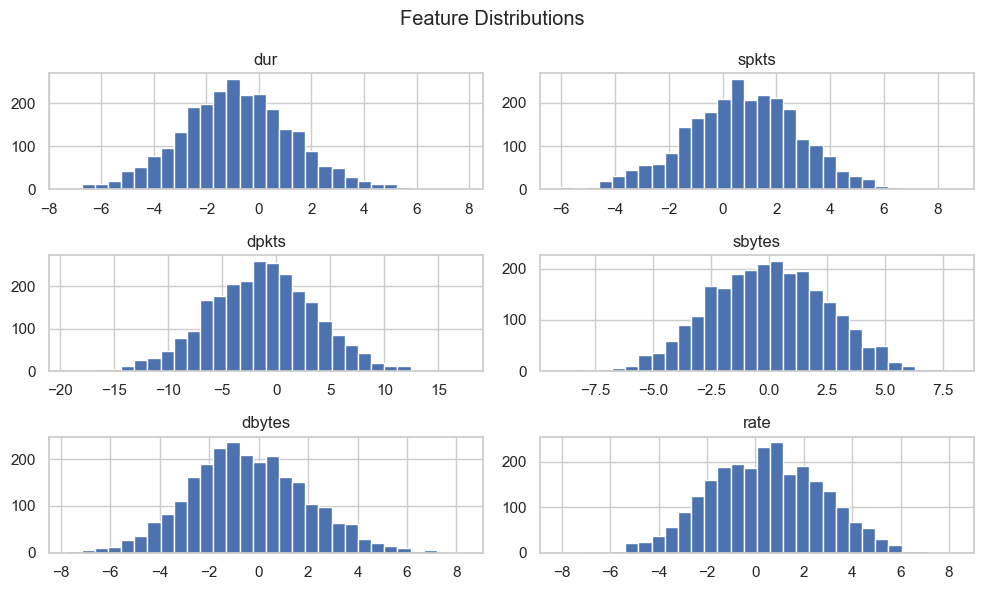

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="label", ax=ax)
ax.set_title("Binary Class Distribution")
ax.set_xticklabels(["Normal", "Attack"])
plt.show()

numeric_cols = df.select_dtypes(include=["number", "bool"]).columns.drop("label", errors="ignore")
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[numeric_cols[:15].tolist() + ["label"]].corr(), cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap")
plt.show()

df[numeric_cols[:6]].hist(figsize=(10, 6), bins=30)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

The pipeline imputes missing values, encodes categorical fields, and scales numeric features. Scaling is essential for linear models and the fusion layer.

In [5]:
TARGET = "label"
X = df.drop(columns=[TARGET], errors="ignore")
y = df[TARGET].astype(int)
X_model = X.drop(columns=["attack_cat"], errors="ignore")

numeric_features = X_model.select_dtypes(include=["number", "bool"]).columns.tolist()
categorical_features = [col for col in X_model.columns if col not in numeric_features]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)
print("Train matrix:", X_train_t.shape, "Test matrix:", X_test_t.shape)

Train matrix: (1875, 20) Test matrix: (625, 20)


## 5. Baseline Models

Baseline models include Logistic Regression, Random Forest, and XGBoost. Each is evaluated using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrix, ROC curve, and PR curve.

In [6]:
def evaluate_model(name, y_true, probabilities):
    predictions = (probabilities >= 0.5).astype(int)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1": f1_score(y_true, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(y_true, probabilities),
        "PR AUC": average_precision_score(y_true, probabilities),
    }

baseline_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=180, max_depth=12, random_state=RANDOM_STATE, n_jobs=1),
    "XGBoost": XGBClassifier(
        n_estimators=160, max_depth=4, learning_rate=0.06, subsample=0.9,
        colsample_bytree=0.9, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=2
    ),
}

probabilities = {}
fitted_models = {}
metrics_rows = []
for name, model in baseline_models.items():
    model.fit(X_train_t, y_train)
    fitted_models[name] = model
    probabilities[name] = model.predict_proba(X_test_t)[:, 1]
    metrics_rows.append(evaluate_model(name, y_test, probabilities[name]))

baseline_metrics = pd.DataFrame(metrics_rows)
display(baseline_metrics)

,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
0,Logistic Regression,0.8640,0.850746,0.756637,0.800937,0.921252,0.889804
1,Random Forest,0.9488,0.975490,0.880531,0.925581,0.988300,0.985586
2,XGBoost,0.9536,0.966825,0.902655,0.933638,0.993169,0.990189


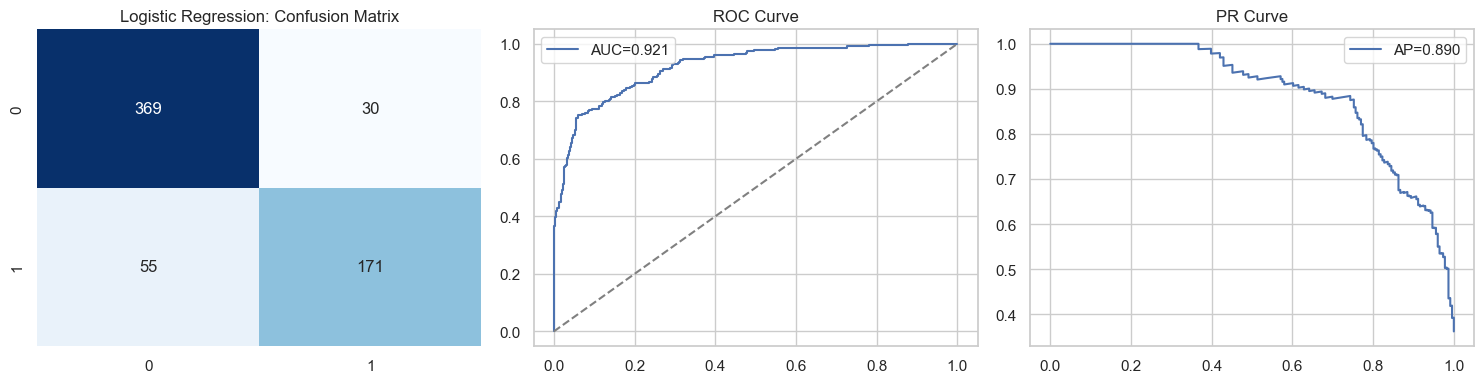

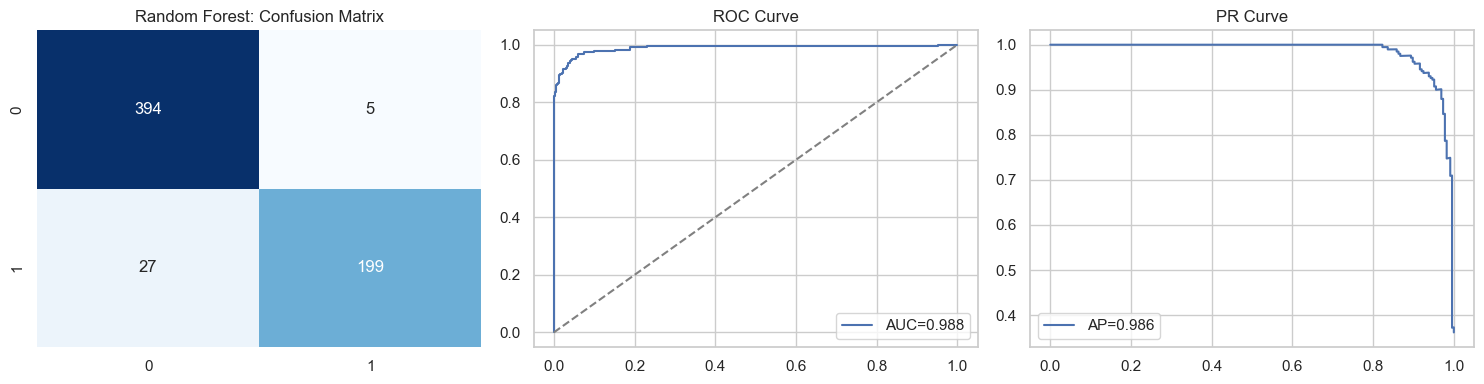

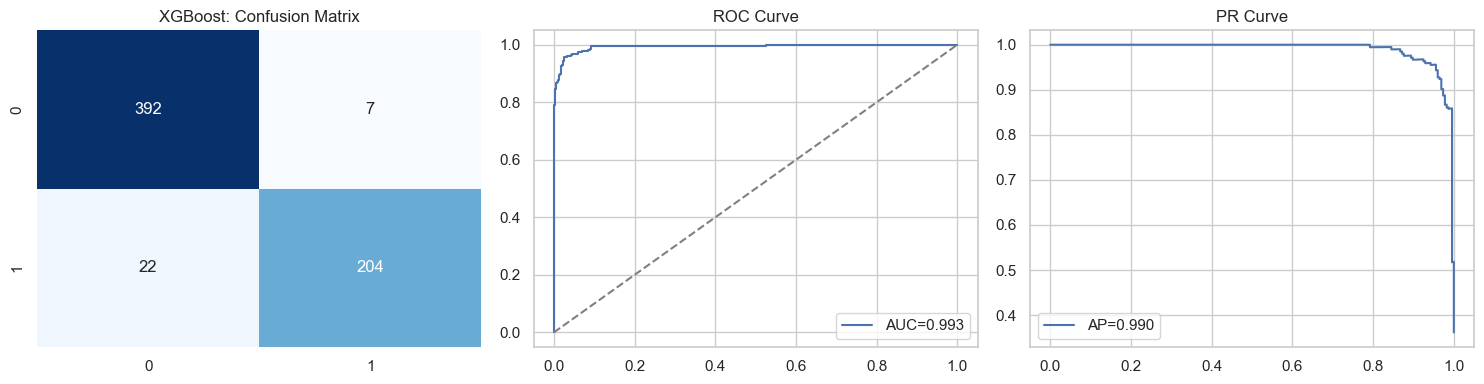

In [7]:
def plot_model_diagnostics(name, y_true, proba):
    pred = (proba >= 0.5).astype(int)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    sns.heatmap(confusion_matrix(y_true, pred), annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
    axes[0].set_title(f"{name}: Confusion Matrix")
    fpr, tpr, _ = roc_curve(y_true, proba)
    axes[1].plot(fpr, tpr, label=f"AUC={roc_auc_score(y_true, proba):.3f}")
    axes[1].plot([0, 1], [0, 1], "--", color="gray")
    axes[1].set_title("ROC Curve")
    axes[1].legend()
    precision, recall, _ = precision_recall_curve(y_true, proba)
    axes[2].plot(recall, precision, label=f"AP={average_precision_score(y_true, proba):.3f}")
    axes[2].set_title("PR Curve")
    axes[2].legend()
    plt.tight_layout()
    plt.show()

for model_name, proba in probabilities.items():
    plot_model_diagnostics(model_name, y_test, proba)

## 6. Hybrid Model

The hybrid model fuses Random Forest probability, XGBoost probability, and normalized Isolation Forest anomaly score. Logistic Regression is used as a meta-classifier fusion layer.

,Model,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC
0,Hybrid RF + XGBoost + Isolation Forest,0.9552,0.975962,0.89823,0.935484,0.991905,0.990144


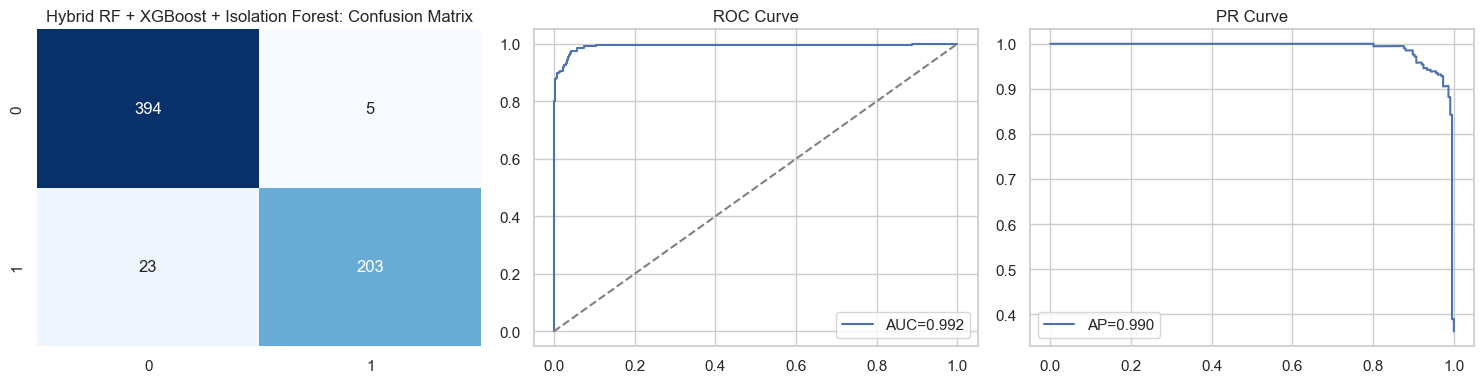

In [8]:
def normalize(values):
    values = np.asarray(values)
    return (values - values.min()) / max(values.max() - values.min(), 1e-9)

isolation = IsolationForest(n_estimators=120, contamination="auto", random_state=RANDOM_STATE)
isolation.fit(X_train_t)
iso_train = normalize(-isolation.decision_function(X_train_t))
iso_test = normalize(-isolation.decision_function(X_test_t))

stacked_train = np.column_stack([
    fitted_models["Random Forest"].predict_proba(X_train_t)[:, 1],
    fitted_models["XGBoost"].predict_proba(X_train_t)[:, 1],
    iso_train,
])
stacked_test = np.column_stack([
    probabilities["Random Forest"],
    probabilities["XGBoost"],
    iso_test,
])

fusion_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
fusion_model.fit(stacked_train, y_train)
hybrid_proba = fusion_model.predict_proba(stacked_test)[:, 1]
probabilities["Hybrid RF + XGBoost + Isolation Forest"] = hybrid_proba
hybrid_metrics = evaluate_model("Hybrid RF + XGBoost + Isolation Forest", y_test, hybrid_proba)
display(pd.DataFrame([hybrid_metrics]))
plot_model_diagnostics("Hybrid RF + XGBoost + Isolation Forest", y_test, hybrid_proba)

## 7. Model Comparison

The table and bar chart compare baseline and hybrid performance across core IDS metrics.

,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.8640,0.850746,0.756637,0.800937,0.921252
1,Random Forest,0.9488,0.975490,0.880531,0.925581,0.988300
2,XGBoost,0.9536,0.966825,0.902655,0.933638,0.993169
3,Hybrid RF + XGBoost + Isolation Forest,0.9552,0.975962,0.898230,0.935484,0.991905


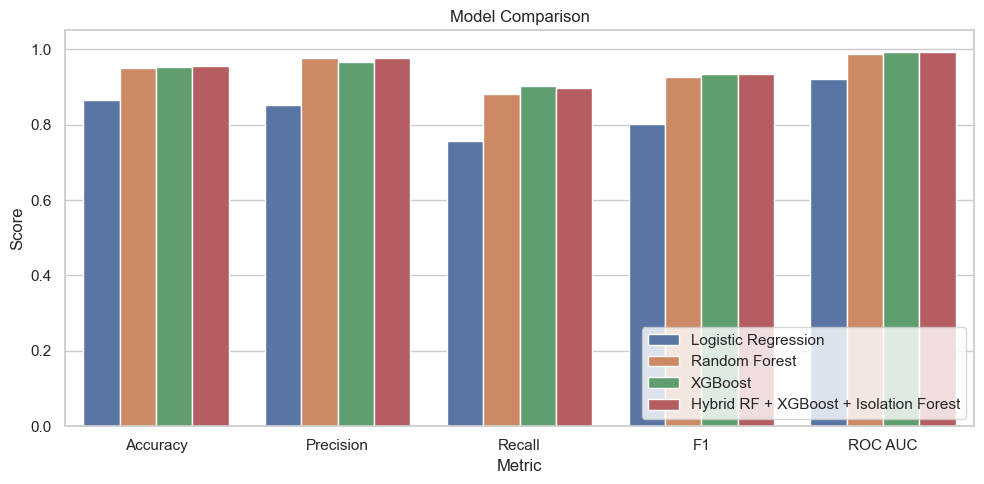

In [9]:
comparison = pd.DataFrame(metrics_rows + [hybrid_metrics])
display(comparison[["Model", "Accuracy", "Precision", "Recall", "F1", "ROC AUC"]])

comparison.to_csv(METRICS_DIR / "notebook_model_metrics.csv", index=False)
comparison.to_json(METRICS_DIR / "notebook_model_metrics.json", orient="records", indent=2)

plot_df = comparison.melt(id_vars="Model", value_vars=["Accuracy", "Precision", "Recall", "F1", "ROC AUC"],
                          var_name="Metric", value_name="Score")
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title("Model Comparison")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 8. Feature Importance

Feature importance is extracted from Random Forest for interpretable ranking of influential traffic attributes.

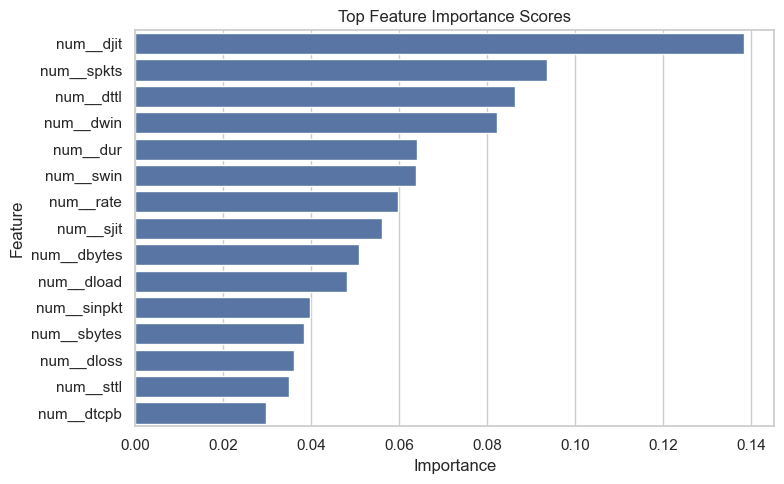

,Feature,Importance
15,num__djit,0.138274
1,num__spkts,0.093586
7,num__dttl,0.086371
19,num__dwin,0.082149
0,num__dur,0.063919
16,num__swin,0.063709
5,num__rate,0.059688
14,num__sjit,0.056065
4,num__dbytes,0.050768
9,num__dload,0.048202


In [10]:
rf = fitted_models["Random Forest"]
if hasattr(preprocessor, "get_feature_names_out"):
    feature_names = preprocessor.get_feature_names_out()
else:
    feature_names = np.array([f"feature_{i}" for i in range(X_train_t.shape[1])])

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_,
}).sort_values("Importance", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=importance, y="Feature", x="Importance", ax=ax)
ax.set_title("Top Feature Importance Scores")
plt.tight_layout()
plt.show()
display(importance)

## 9. Final Interpretation

The best model is selected by F1-score and ROC-AUC because IDS evaluation must balance detection capability and false alarms. Hybrid fusion can improve performance by combining supervised classification strength with anomaly evidence, making the detector more robust to diverse intrusion behavior. The research conclusion is that hybrid ML is a suitable applied, experimental, quantitative, and comparative approach for IDS design on UNSW-NB15-style network traffic.

In [11]:
best_by_f1 = comparison.sort_values("F1", ascending=False).iloc[0]
print(f"Best model by F1-score: {best_by_f1['Model']} (F1={best_by_f1['F1']:.4f}, ROC AUC={best_by_f1['ROC AUC']:.4f})")
print("Research conclusion: hybrid IDS fusion provides a structured way to combine complementary model evidence for intrusion detection.")

Best model by F1-score: Hybrid RF + XGBoost + Isolation Forest (F1=0.9355, ROC AUC=0.9919)
Research conclusion: hybrid IDS fusion provides a structured way to combine complementary model evidence for intrusion detection.
